In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import pathlib
import scipy
from scipy import constants as const
from astropy import constants as astroconst
from scipy.integrate import quad

In [3]:
isochrones = pd.read_csv('/Users/liambrake/Desktop/CIRCUMBINARY/Sim1_unlogged.csv', header=0)
print(isochrones.head())

   log(t(yr))  log(L/Lo)     logTe      M/Mo   [M/H]         t(yr)       L/Lo  \
0   -9.000000   1.443863  3.621381  1.000000  0.3269  1.000000e-09  27.788365   
1    4.141485   1.316371  3.627306  1.000000  0.3269  1.385113e+04  20.719090   
2    4.442515   1.210284  3.631647  1.000000  0.3269  2.770225e+04  16.228718   
3    4.618606   1.146384  3.633972  1.000000  0.3269  4.155338e+04  14.008238   
4    4.743545   1.114610  3.635062  0.999999  0.3269  5.540450e+04  13.019964   

            Te  
0  4181.970838  
1  4239.417309  
2  4282.005089  
3  4304.993207  
4  4315.803890  


In [4]:
# Kopparapu coefficients
seffsun  = np.array([1.776, 1.107, 0.356, 0.320, 1.188, 0.99])
a = np.array([2.136e-4, 1.332e-4, 6.171e-5, 5.547e-5, 1.433e-4, 1.209e-4])
b = np.array([2.533e-8, 1.580e-8, 1.698e-9, 1.526e-9, 1.707e-8, 1.404e-8])
c = np.array([-1.332e-11, -8.308e-12, -3.198e-12, -2.874e-12, -8.968e-12, -7.418e-12])
d = np.array([-3.097e-15, -1.931e-15, -5.575e-16, -5.011e-16, -2.084e-15, -1.713e-15])

In [5]:
# HZ Coefficients from Kopparapu
hz_labels = [
    "Recent Venus",        # 0
    "Runaway Greenhouse",  # 1  <-- conservative inner
    "Maximum Greenhouse",  # 2  <-- conservative outer
    "Early Mars",          # 3  <-- optimistic outer
    "5ME Runaway",         # 4
    "0.1ME Runaway"        # 5
]

In [6]:
Tstar = isochrones['Te'].to_numpy() - 5780.0

In [7]:
for i, label in enumerate(hz_labels):
    seff_i = seffsun[i] + a[i]*Tstar + b[i]*(Tstar**2) + c[i]*(Tstar**3) + d[i]*(Tstar**4)
    seff_i = np.where(seff_i > 0, seff_i, np.nan)
    col_seff = f"S_eff_{label.replace(' ', '_')}"
    col_dist = f"d_AU_{label.replace(' ', '_')}"
    isochrones[col_seff] = seff_i
    isochrones[col_dist] = np.sqrt(isochrones['L/Lo'].to_numpy() / seff_i)

In [8]:
isochrones.to_csv('/Users/liambrake/Desktop/CIRCUMBINARY/Sim1_with_HZ.csv')

/var/folders/gd/_czs0x790n1gq375shf4np_m0000gn/T/ipykernel_52243/2551512353.py:22: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 1e10)


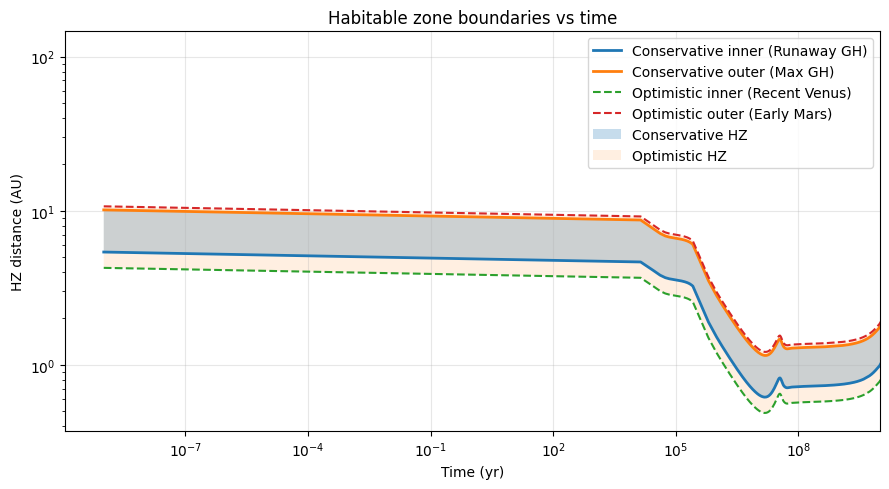

In [9]:
# conservative and optimistic boundaries:
# conservative inner = Runaway Greenhouse (index 1)
# conservative outer = Maximum Greenhouse (index 2)
# optimistic inner = Recent Venus (index 0)
# optimistic outer = Early Mars (index 3)

t = isochrones['t(yr)']

plt.figure(figsize=(9,5))

plt.semilogx(t, isochrones['d_AU_Runaway_Greenhouse'], lw=2, label='Conservative inner (Runaway GH)')
plt.semilogx(t, isochrones['d_AU_Maximum_Greenhouse'], lw=2, label='Conservative outer (Max GH)')
plt.semilogx(t, isochrones['d_AU_Recent_Venus'], lw=1.5, ls='--', label='Optimistic inner (Recent Venus)')
plt.semilogx(t, isochrones['d_AU_Early_Mars'], lw=1.5, ls='--', label='Optimistic outer (Early Mars)')

plt.fill_between(t, isochrones['d_AU_Runaway_Greenhouse'], isochrones['d_AU_Maximum_Greenhouse'],
                 alpha=0.25, label='Conservative HZ')
plt.fill_between(t, isochrones['d_AU_Recent_Venus'], isochrones['d_AU_Early_Mars'],
                 alpha=0.12, label='Optimistic HZ')

plt.xlabel('Time (yr)')
plt.xlim(0, 1e10)
plt.ylabel('HZ distance (AU)')
plt.yscale('log')
plt.title('Habitable zone boundaries vs time')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()